In [ ]:
from pathlib import Path

import datetime
import pandas as pd
from jinja2 import Environment, FileSystemLoader, StrictUndefined

from calitp_data_analysis import gcs_pandas
from calitp_data_analysis.sql import get_engine
from shared_utils.catalog_utils import get_catalog
from shared_utils.rt_dates import DATES

g = gcs_pandas.GCSPandas()

# get jinja environment for substituting in queries
jinja_env = Environment(
    loader=FileSystemLoader(Path("queries")),
    undefined=StrictUndefined,
    autoescape=False,  # nosec B701 - rendering SQL, not markup
)

jinja_env.filters["sql_in"] = lambda values: "(" + ", ".join(f"'{v}'" for v in values) + ")"
jinja_env.filters["sql_in_timestamps"] = (
    lambda values: "(" + ", ".join(f"timestamp('{v}')" for v in values) + ")"
)

# bigquery engine from calitp_date_analysis
engine = get_engine()

def run_query(name: str, **params) -> pd.DataFrame:
    """Render queries/<name>.sql with params and run it against BigQuery."""
    return pd.read_sql_query(jinja_env.get_template(f"{name}.sql").render(**params), engine)

## Constants

In [32]:
# The feed to examine TODO: support multiple
GTFS_DATASET_NAME = "Bay Area 511 SamTrans Schedule"
# Sample dates to look at
dates_values = DATES.values()
print(len(dates_values))

85


## Get data

In [33]:
# Get feed key for the target feed:
feed_keys_to_dates = run_query(
    "feed_keys",
    DATES=dates_values,
    GTFS_DATASET_NAME=GTFS_DATASET_NAME,
)
feed_keys_to_dates

/home/mrtopsyt/data-analyses/.venv/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


,tu_base64_url,schedule_feed_key,date
0,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,4dfefaf518766d1cfc3d254a65e4295e,2026-06-10
1,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,0215a1c49f081dc0a7eb1e118ea91229,2024-12-11
2,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,15b3a87c05331f6d0e0b73cf340bfc5b,2025-02-12
3,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,1d276b06a3c6ff0d661e25035982ead7,2024-03-13
4,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,25c80082b079cb7fab299c7015aa7470,2023-07-12
...,...,...,...
80,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,c1c5d0b862094fbf640e18075b290861,2025-09-30
81,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,c1c5d0b862094fbf640e18075b290861,2025-09-24
82,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,c7ab222b14ca19ad45369c228ac16783,2025-09-23
83,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,c7bc4bc9de15ff685470b0de7578d313,2026-01-14


In [34]:
# Count fct_stop_time_metrics rows per trip updates feed per date
tu_urls = feed_keys_to_dates["tu_base64_url"].dropna().unique()

stop_time_metrics_counts = run_query(
    "stop_time_metrics_counts",
    DATES=dates_values,
    TU_URLS=tu_urls,
)
stop_time_metrics_counts

,tu_base64_url,service_date,n_stop_time_metrics
0,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,2025-12-17,59708
1,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,2026-01-14,59560
2,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,2026-04-08,36667
3,aHR0cHM6Ly9hcGkuNTExLm9yZy90cmFuc2l0L3RyaXB1cG...,2026-06-10,60858


In [35]:
# Get the VP based stop times
gtfs_analytics_catalog = get_catalog("gtfs_analytics_data")
stop_time_metrics_counts["vp_uri"] = (
    f"{gtfs_analytics_catalog['rt_stop_times']['dir']}{gtfs_analytics_catalog['rt_stop_times']['stage3']}_" 
    + stop_time_metrics_counts["service_date"].astype(str)
    + ".parquet"
)


In [36]:
# The TU based stop times, plus the trips to filter the statewide VP files with.
# Both are limited to the dates that actually have stop time metrics.
stm_dates = stop_time_metrics_counts["service_date"].astype(str).tolist()
stm_urls = stop_time_metrics_counts["tu_base64_url"].unique()

operator_trips = run_query(
    "operator_trips",
    DATES=stm_dates,
    GTFS_DATASET_NAME=GTFS_DATASET_NAME,
)

tu_stop_times = run_query(
    "tu_stop_times",
    DATES=stm_dates,
    TU_URLS=stm_urls,
    GTFS_DATASET_NAME=GTFS_DATASET_NAME,
)

In [37]:
tu_stop_times.head()

,trip_instance_key,service_date,stop_id,stop_sequence,tu_arrival_time,n_predictions
0,0008d298e3f42cea9e00cfddb076fdd0,2026-06-10,341081,1,2026-06-10 07:18:00,79
1,0008d298e3f42cea9e00cfddb076fdd0,2026-06-10,341185,2,2026-06-10 07:18:17,85
2,0008d298e3f42cea9e00cfddb076fdd0,2026-06-10,341622,3,2026-06-10 07:22:00,90
3,0008d298e3f42cea9e00cfddb076fdd0,2026-06-10,341060,4,2026-06-10 07:18:26,90
4,0008d298e3f42cea9e00cfddb076fdd0,2026-06-10,341957,5,2026-06-10 07:19:20,90


In [38]:
# Get the scheduled stop times.
# One feed version can span several service dates, so this is fewer feeds than dates.
schedule_feed_keys = feed_keys_to_dates.loc[
    feed_keys_to_dates["date"].astype(str).isin(stm_dates), "schedule_feed_key"
].unique()

schedule_feeds = run_query("schedule_feeds", FEED_KEYS=schedule_feed_keys)

schedule_stop_times = run_query(
    "schedule_stop_times",
    DATES=stm_dates,
    GTFS_DATASET_NAME=GTFS_DATASET_NAME,
    FEED_VALID_FROMS=schedule_feeds["feed_valid_from"].astype(str),
    FEED_KEYS=schedule_feed_keys,
)
schedule_stop_times.head()

,trip_instance_key,service_date,stop_id,stop_sequence,schedule_arrival_time,schedule_departure_time
0,00003a69e91a4ef117840d081cdbe355,2025-12-17,332014,1,2025-12-18 00:15:00,2025-12-18 00:15:00
1,00003a69e91a4ef117840d081cdbe355,2025-12-17,332170,2,2025-12-18 00:17:01,2025-12-18 00:17:01
2,00003a69e91a4ef117840d081cdbe355,2025-12-17,332232,3,2025-12-18 00:18:03,2025-12-18 00:18:03
3,00003a69e91a4ef117840d081cdbe355,2025-12-17,332238,4,2025-12-18 00:18:42,2025-12-18 00:18:42
4,00003a69e91a4ef117840d081cdbe355,2025-12-17,332215,5,2025-12-18 00:19:49,2025-12-18 00:19:49


In [39]:
# Get matching VP stop times

VP_COLS = ["trip_instance_key", "stop_sequence", "arrival_time", "stop_meters", "shape_array_key"]

# trip_instance_key is unique per trip per service date, so it both filters the
# statewide VP files down to this operator and carries the date back onto the
# joined rows. Pushing the filter into the read gets ~200k rows off GCS instead
# of the ~9.6M statewide rows these four files hold.
trip_dates = operator_trips.set_index("trip_instance_key")["service_date"]

vp_stop_times = g.read_parquet(
    stop_time_metrics_counts["vp_uri"].tolist(),
    columns=VP_COLS,
    filters=[("trip_instance_key", "in", set(trip_dates.index))],
).rename(columns={"arrival_time": "vp_arrival_time"})

vp_tu_stop_times = vp_stop_times.merge(
    tu_stop_times.drop(columns=["service_date"]),
    on=["trip_instance_key", "stop_sequence"],
    how="outer",
    indicator="source",
)
vp_tu_stop_times["source"] = vp_tu_stop_times["source"].cat.rename_categories(
    {"left_only": "vp_only", "right_only": "tu_only"}
)

# Outer again, so scheduled stops that neither VP nor TU ever reported survive.
vp_tu_stop_times = vp_tu_stop_times.merge(
    schedule_stop_times.drop(columns=["service_date"]),
    on=["trip_instance_key", "stop_sequence"],
    how="outer",
    indicator="has_schedule",
    suffixes=("", "_schedule"),
)
vp_tu_stop_times["has_schedule"] = vp_tu_stop_times["has_schedule"] != "left_only"
# The two stop_id columns agree wherever both are populated, so keep one.
vp_tu_stop_times["stop_id"] = vp_tu_stop_times["stop_id"].fillna(
    vp_tu_stop_times["stop_id_schedule"]
)
vp_tu_stop_times = vp_tu_stop_times.drop(columns=["stop_id_schedule"])
# Rows only the schedule knows about have no VP/TU source yet.
vp_tu_stop_times["source"] = (
    vp_tu_stop_times["source"].cat.add_categories("schedule_only").fillna("schedule_only")
)

vp_tu_stop_times["service_date"] = vp_tu_stop_times["trip_instance_key"].map(trip_dates)

print(
    vp_tu_stop_times.groupby(["service_date", "source"], observed=True)
    .size()
    .unstack(fill_value=0)
)
vp_tu_stop_times.head()


source        vp_only  tu_only   both  schedule_only
service_date                                        
2025-12-17       1594    10608  49100           2212
2026-01-14       1151    10809  48751           2775
2026-04-08      19911     6742  29925           6907
2026-06-10       1465    13132  47726           3871


,trip_instance_key,stop_sequence,vp_arrival_time,stop_meters,shape_array_key,stop_id,tu_arrival_time,n_predictions,source,schedule_arrival_time,schedule_departure_time,has_schedule,service_date
0,00003a69e91a4ef117840d081cdbe355,1,2025-12-17 00:18:17,1.613893,fd6a664f2ca715017d46996e1cf0c8e0,332014,NaT,NaN,vp_only,2025-12-18 00:15:00,2025-12-18 00:15:00,True,2025-12-17
1,00003a69e91a4ef117840d081cdbe355,2,2025-12-17 00:20:53,734.456238,fd6a664f2ca715017d46996e1cf0c8e0,332170,NaT,NaN,vp_only,2025-12-18 00:17:01,2025-12-18 00:17:01,True,2025-12-17
2,00003a69e91a4ef117840d081cdbe355,3,NaT,NaN,NaN,332232,NaT,NaN,schedule_only,2025-12-18 00:18:03,2025-12-18 00:18:03,True,2025-12-17
3,00003a69e91a4ef117840d081cdbe355,4,2025-12-17 00:21:28,1359.918670,fd6a664f2ca715017d46996e1cf0c8e0,332238,NaT,NaN,vp_only,2025-12-18 00:18:42,2025-12-18 00:18:42,True,2025-12-17
4,00003a69e91a4ef117840d081cdbe355,5,2025-12-17 00:22:40,1772.076525,fd6a664f2ca715017d46996e1cf0c8e0,332215,NaT,NaN,vp_only,2025-12-18 00:19:49,2025-12-18 00:19:49,True,2025-12-17


## Analysis

### Data availability

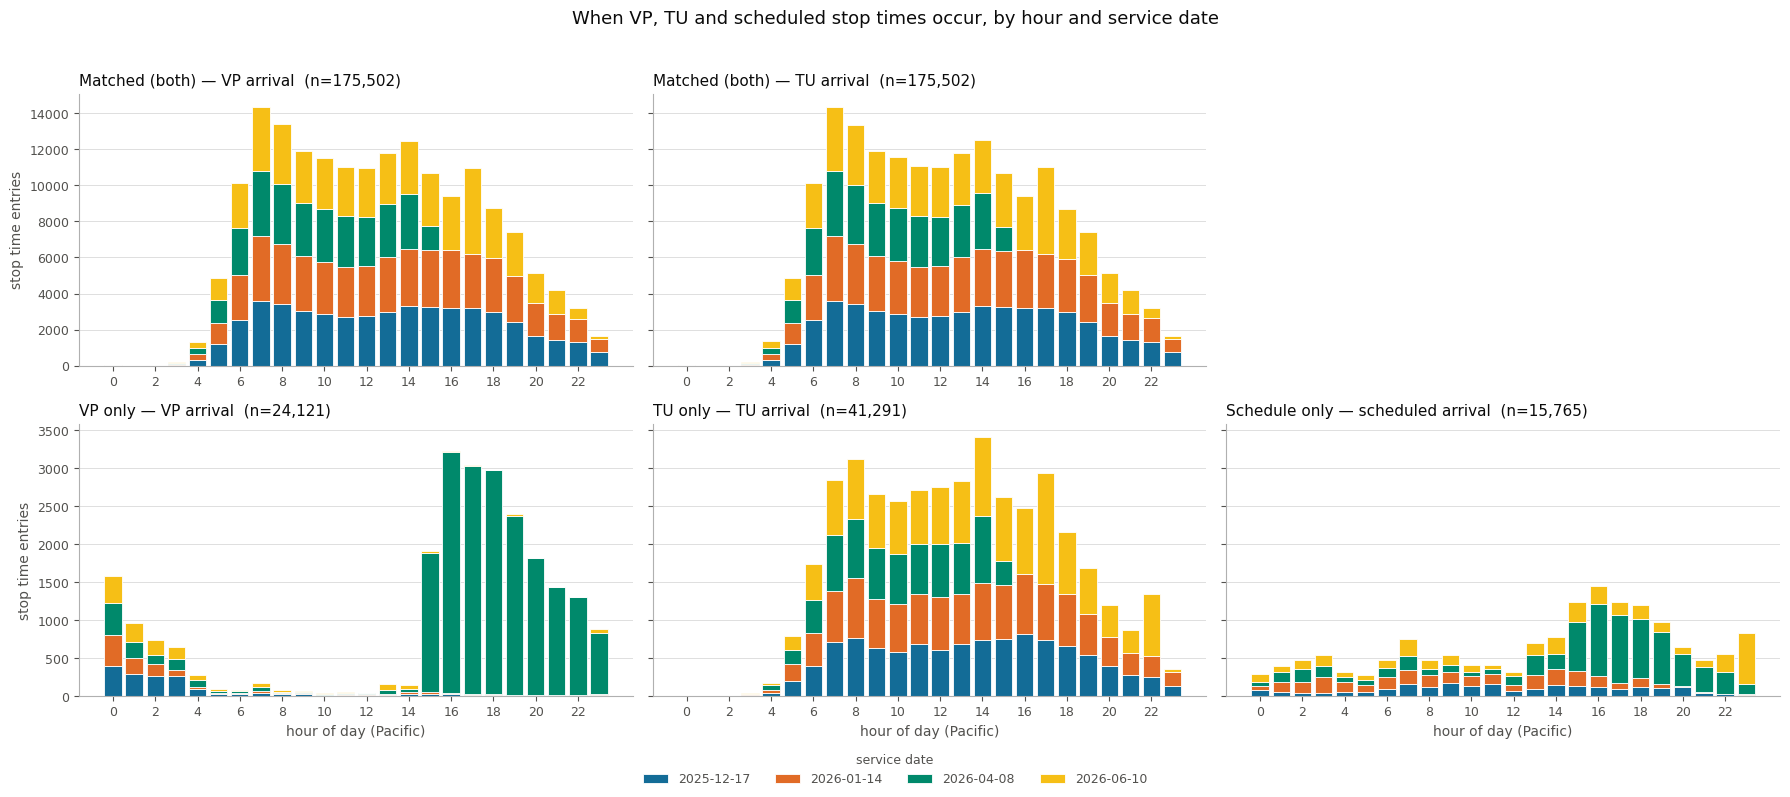

In [40]:
# Hour of day distribution of stop time entries, stacked by service date
import matplotlib.pyplot as plt
import numpy as np
from calitp_data_analysis.calitp_color_palette import CALITP_CATEGORY_BOLD_COLORS

# Light mode, pinned explicitly so the figure does not inherit a dark notebook
# theme (a transparent background would put this near-black text on dark gray).
SURFACE = "#ffffff"
INK = "#0b0b0b"
INK_MUTED = "#52514e"
GRID = "#d9d9d9"
AXIS = "#b0b0b0"

# Slots 1, 2, 4, 3: green sits between orange and yellow so the two warmest
# hues are never adjacent segments within a stack.
DATE_COLORS = [CALITP_CATEGORY_BOLD_COLORS[i] for i in (0, 1, 3, 2)]

# grid position -> (source, which arrival time to bin, panel title)
PANELS = {
    (0, 0): ("both", "vp_arrival_time", "Matched (both) — VP arrival"),
    (0, 1): ("both", "tu_arrival_time", "Matched (both) — TU arrival"),
    (1, 0): ("vp_only", "vp_arrival_time", "VP only — VP arrival"),
    (1, 1): ("tu_only", "tu_arrival_time", "TU only — TU arrival"),
    (1, 2): ("schedule_only", "schedule_arrival_time", "Schedule only — scheduled arrival"),
}

service_dates = sorted(vp_tu_stop_times["service_date"].unique())
color_by_date = dict(zip(service_dates, DATE_COLORS))

# Rows share a y axis: the two "both" panels are the same matched rows counted
# two ways, and the bottom row is the three mutually exclusive misses. The rows
# differ in magnitude by ~5x, so their scales are left independent.
fig, axes = plt.subplots(
    2, 3, figsize=(18, 8), sharex=True, sharey="row", facecolor=SURFACE
)
fig.delaxes(axes[0, 2])  # only two ways to count a matched row

for (row, col), (src, time_col, title) in PANELS.items():
    ax = axes[row, col]
    subset = vp_tu_stop_times.loc[vp_tu_stop_times["source"] == src]
    hourly = (
        subset.groupby([subset[time_col].dt.hour, "service_date"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=range(24), columns=service_dates, fill_value=0)
    )

    bottom = np.zeros(24)
    for service_date in service_dates:
        heights = hourly[service_date].to_numpy()
        ax.bar(
            hourly.index,
            heights,
            bottom=bottom,
            width=0.82,
            color=color_by_date[service_date],
            label=str(service_date),
            edgecolor=SURFACE,
            linewidth=0.6,
        )
        bottom += heights

    ax.set_facecolor(SURFACE)
    ax.set_title(f"{title}  (n={len(subset):,})", fontsize=11, loc="left", color=INK)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=INK_MUTED, labelsize=9, labelbottom=True)

for ax in axes[:, 0]:
    ax.set_ylabel("stop time entries", fontsize=10, color=INK_MUTED)
for ax in axes[1, :]:
    ax.set_xlabel("hour of day (Pacific)", fontsize=10, color=INK_MUTED)

handles, labels = axes[0, 0].get_legend_handles_labels()
legend = fig.legend(
    handles,
    labels,
    title="service date",
    loc="lower center",
    ncol=len(service_dates),
    frameon=False,
    fontsize=9,
    title_fontsize=9,
)
legend.get_title().set_color(INK_MUTED)
for text in legend.get_texts():
    text.set_color(INK_MUTED)

fig.suptitle(
    "When VP, TU and scheduled stop times occur, by hour and service date",
    fontsize=13,
    x=0.5,
    y=0.98,
    color=INK,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()
# this plot seems to show that VP only trips have a strong time pattern (mornings on all dates, evenings specifically on one date. 
# this matches hypothesis that TU is producing trips for certain dates only, because it runs on data that is partitioned by UTC date rather than service_date
# however, TU arrivals are occuring for all dates evenly. this suggests that there are significant data availability issues for the VP data, although
# could also infer that erroneous trips are occuring


In [41]:
# TODO - would be interesting to know if missing VP trips are clustered on the same trips and/or same stops
# many clustered on same trip - means that vp is either consistently unavailable for some trips 
# or that trips are being dropped by the pipeline
# many clustered on same stop - issue with GPS/cellular outages at specific stops
# no clustering - VP pipeline is potentially dropping stops

### Basic difference analysis

In [42]:
vp_tu_stop_times_cleaned = vp_tu_stop_times.loc[
    (
        (vp_tu_stop_times["service_date"] != datetime.date(2026, 4, 8))
        & (vp_tu_stop_times["source"] == "both")
    )
].copy()
vp_tu_stop_times_cleaned["vp_tu_difference"] = (
    vp_tu_stop_times_cleaned["vp_arrival_time"] - vp_tu_stop_times_cleaned["tu_arrival_time"]
).abs()
vp_tu_stop_times_cleaned["vp_tu_difference_seconds"] = vp_tu_stop_times_cleaned["vp_tu_difference"].dt.seconds
vp_tu_stop_times_cleaned.head()

,trip_instance_key,stop_sequence,vp_arrival_time,stop_meters,shape_array_key,stop_id,tu_arrival_time,n_predictions,source,schedule_arrival_time,schedule_departure_time,has_schedule,service_date,vp_tu_difference,vp_tu_difference_seconds
81,0008d298e3f42cea9e00cfddb076fdd0,2,2026-06-10 07:18:28,875.071896,5c9e314c9eb12d2f42a1172287709df2,341185,2026-06-10 07:18:17,85.0,both,2026-06-10 07:15:17,2026-06-10 07:15:17,True,2026-06-10,0 days 00:00:11,11
82,0008d298e3f42cea9e00cfddb076fdd0,3,2026-06-10 07:21:44,3452.935577,5c9e314c9eb12d2f42a1172287709df2,341622,2026-06-10 07:22:00,90.0,both,2026-06-10 07:22:00,2026-06-10 07:22:00,True,2026-06-10,0 days 00:00:16,16
83,0008d298e3f42cea9e00cfddb076fdd0,4,2026-06-10 07:23:34,4380.034253,5c9e314c9eb12d2f42a1172287709df2,341060,2026-06-10 07:18:26,90.0,both,2026-06-10 07:27:26,2026-06-10 07:27:26,True,2026-06-10,0 days 00:05:08,308
84,0008d298e3f42cea9e00cfddb076fdd0,5,2026-06-10 07:23:50,4533.545296,5c9e314c9eb12d2f42a1172287709df2,341957,2026-06-10 07:19:20,90.0,both,2026-06-10 07:28:20,2026-06-10 07:28:20,True,2026-06-10,0 days 00:04:30,270
85,0008d298e3f42cea9e00cfddb076fdd0,6,2026-06-10 07:24:41,4958.540713,5c9e314c9eb12d2f42a1172287709df2,341271,2026-06-10 07:22:49,90.0,both,2026-06-10 07:30:49,2026-06-10 07:30:49,True,2026-06-10,0 days 00:01:52,112


In [43]:
# Headline difference analysis
vp_tu_stop_times_grouped_by_date = vp_tu_stop_times_cleaned.groupby("service_date")["vp_tu_difference_seconds"]
diff_stats = pd.DataFrame(
    {
        "mean": vp_tu_stop_times_grouped_by_date.mean(),
        "p5": vp_tu_stop_times_grouped_by_date.quantile(0.05),
        "p25": vp_tu_stop_times_grouped_by_date.quantile(0.25),
        "p50": vp_tu_stop_times_grouped_by_date.quantile(0.50),
        "p75": vp_tu_stop_times_grouped_by_date.quantile(0.75),
        "p90": vp_tu_stop_times_grouped_by_date.quantile(0.90),
        "p95": vp_tu_stop_times_grouped_by_date.quantile(0.95),
        "std_dev": vp_tu_stop_times_grouped_by_date.std(),
    }
)
diff_stats.index.name = "service_date"
diff_stats.round(1)

,mean,p5,p25,p50,p75,p90,p95,std_dev
service_date,,,,,,,,
2025-12-17,41.4,2.0,11.0,23.0,42.0,77.0,118.0,106.5
2026-01-14,42.7,2.0,11.0,24.0,43.0,79.0,123.0,109.4
2026-06-10,58.2,2.0,12.0,25.0,49.0,109.0,194.0,164.5


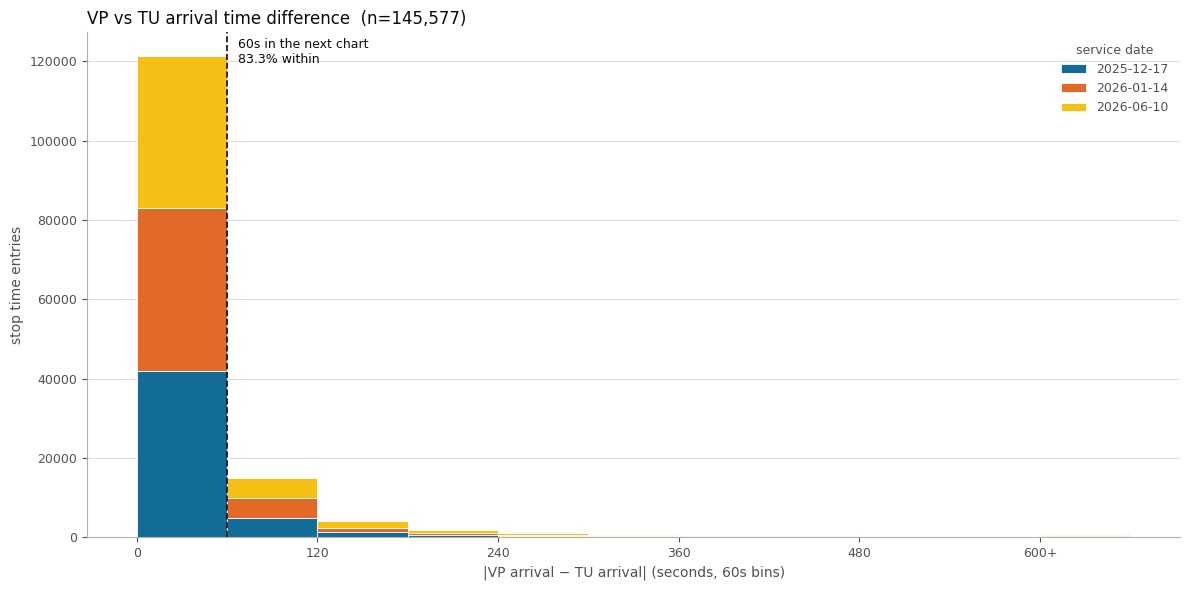

In [44]:
SMALL_HIST = 60
# The tail runs to ~85 min but 99.4% of rows are under 10 min, so the axis stops
MAX_SECONDS = 600
TICK_SECONDS = 120  # a multiple of the bin width that divides MAX_SECONDS evenly

diff_seconds = vp_tu_stop_times_cleaned["vp_tu_difference"].dt.total_seconds()
bins = np.arange(0, MAX_SECONDS + 2 * SMALL_HIST, SMALL_HIST)
within_noise = (diff_seconds < SMALL_HIST).mean()

# Reuse color_by_date so a date keeps the color it has in the hour of day plot.
# 2026-04-08 is filtered out of the cleaned frame; the remaining dates keep their
# own colors rather than being repainted.
cleaned_dates = [
    d for d in service_dates if d in set(vp_tu_stop_times_cleaned["service_date"])
]

fig, ax = plt.subplots(figsize=(12, 6), facecolor=SURFACE)
ax.hist(
    [
        diff_seconds[vp_tu_stop_times_cleaned["service_date"] == d].clip(upper=MAX_SECONDS)
        for d in cleaned_dates
    ],
    bins=bins,
    stacked=True,
    color=[color_by_date[d] for d in cleaned_dates],
    label=[str(d) for d in cleaned_dates],
    edgecolor=SURFACE,
    linewidth=0.6,
)

# The first bin is the noise floor; mark its right edge.
ax.axvline(SMALL_HIST, color=INK, linewidth=1.2, linestyle="--")
ax.annotate(
    f"{SMALL_HIST}s in the next chart \n{within_noise:.1%} within",
    xy=(SMALL_HIST, ax.get_ylim()[1]),
    xytext=(8, -22),
    textcoords="offset points",
    fontsize=9,
    color=INK,
)

ax.set_facecolor(SURFACE)
ax.set_title(
    f"VP vs TU arrival time difference  (n={len(diff_seconds):,})",
    fontsize=12,
    loc="left",
    color=INK,
)
ax.set_xlabel(
    f"|VP arrival − TU arrival| (seconds, {SMALL_HIST}s bins)",
    fontsize=10,
    color=INK_MUTED,
)
ax.set_ylabel("stop time entries", fontsize=10, color=INK_MUTED)
# The last tick sits on the overflow bin, so it gets a "+" label.
ticks = np.arange(0, MAX_SECONDS + TICK_SECONDS, TICK_SECONDS)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:.0f}" for t in ticks[:-1]] + [f"{MAX_SECONDS}+"])
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(title="service date", frameon=False, fontsize=9, title_fontsize=9)
legend.get_title().set_color(INK_MUTED)
for text in legend.get_texts():
    text.set_color(INK_MUTED)

fig.tight_layout()
plt.show()


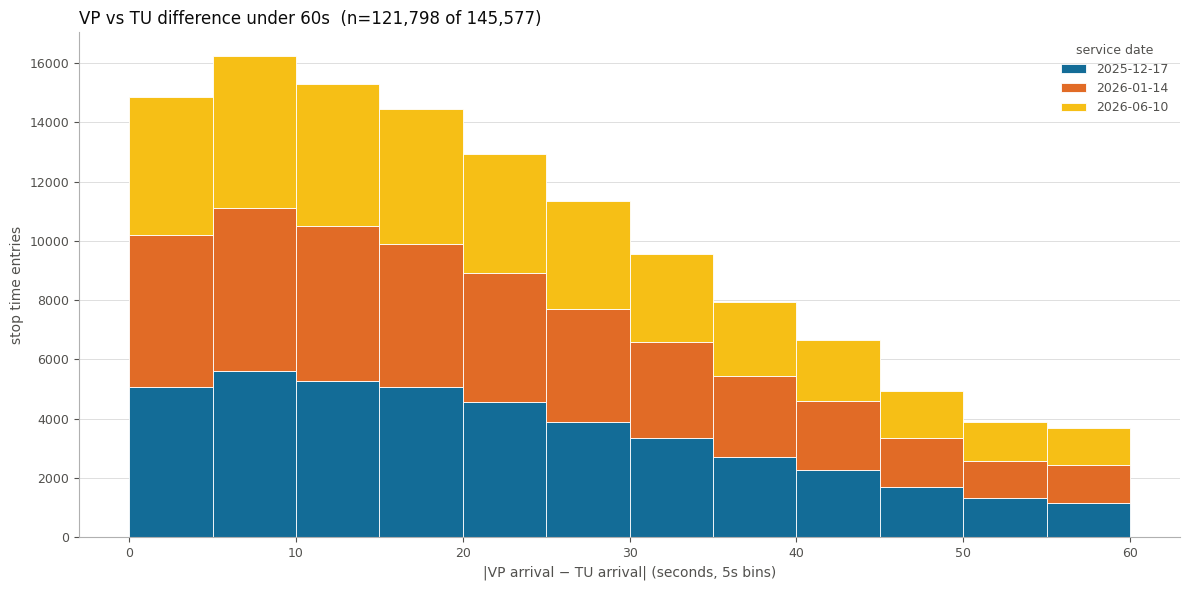

In [45]:
# Zoom in on the sub-minute differences to examine distribution there
SMALL_HIST_SECONDS = 5
CUTOFF_SECONDS = 60

diff_under_minute = diff_seconds[diff_seconds <= CUTOFF_SECONDS]
fine_bins = np.arange(0, CUTOFF_SECONDS + SMALL_HIST_SECONDS, SMALL_HIST_SECONDS)
cleaned_service_dates = vp_tu_stop_times_cleaned["service_date"]

fig, ax = plt.subplots(figsize=(12, 6), facecolor=SURFACE)
ax.hist(
    [
        diff_under_minute[cleaned_service_dates.loc[diff_under_minute.index] == d]
        for d in cleaned_dates
    ],
    bins=fine_bins,
    stacked=True,
    color=[color_by_date[d] for d in cleaned_dates],
    label=[str(d) for d in cleaned_dates],
    edgecolor=SURFACE,
    linewidth=0.6,
)

ax.set_facecolor(SURFACE)
ax.set_title(
    f"VP vs TU difference under {CUTOFF_SECONDS}s  "
    f"(n={len(diff_under_minute):,} of {len(diff_seconds):,})",
    fontsize=12,
    loc="left",
    color=INK,
)
ax.set_xlabel(
    f"|VP arrival − TU arrival| (seconds, {SMALL_HIST_SECONDS}s bins)",
    fontsize=10,
    color=INK_MUTED,
)
ax.set_ylabel("stop time entries", fontsize=10, color=INK_MUTED)
ax.set_xticks(np.arange(0, CUTOFF_SECONDS + 10, 10))
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(title="service date", frameon=False, fontsize=9, title_fontsize=9)
legend.get_title().set_color(INK_MUTED)
for text in legend.get_texts():
    text.set_color(INK_MUTED)

fig.tight_layout()
plt.show()


### Outlier Investigation

In [46]:
OUTLIER_DIFFERENCE = datetime.timedelta(seconds=120)
vp_tu_stop_times_outliers = vp_tu_stop_times_cleaned.loc[
    vp_tu_stop_times_cleaned["vp_tu_difference"] > OUTLIER_DIFFERENCE
].copy()
print(len(vp_tu_stop_times_outliers))

9201


In [47]:
print(len(vp_tu_stop_times_outliers) / len(vp_tu_stop_times_cleaned))

0.06320366541417943


In [48]:
vp_tu_stop_times_outliers.head()

,trip_instance_key,stop_sequence,vp_arrival_time,stop_meters,shape_array_key,stop_id,tu_arrival_time,n_predictions,source,schedule_arrival_time,schedule_departure_time,has_schedule,service_date,vp_tu_difference,vp_tu_difference_seconds
83,0008d298e3f42cea9e00cfddb076fdd0,4,2026-06-10 07:23:34,4380.034253,5c9e314c9eb12d2f42a1172287709df2,341060,2026-06-10 07:18:26,90.0,both,2026-06-10 07:27:26,2026-06-10 07:27:26,True,2026-06-10,0 days 00:05:08,308
84,0008d298e3f42cea9e00cfddb076fdd0,5,2026-06-10 07:23:50,4533.545296,5c9e314c9eb12d2f42a1172287709df2,341957,2026-06-10 07:19:20,90.0,both,2026-06-10 07:28:20,2026-06-10 07:28:20,True,2026-06-10,0 days 00:04:30,270
86,0008d298e3f42cea9e00cfddb076fdd0,7,2026-06-10 07:25:47,5505.371128,5c9e314c9eb12d2f42a1172287709df2,341097,2026-06-10 07:29:01,90.0,both,2026-06-10 07:34:01,2026-06-10 07:34:01,True,2026-06-10,0 days 00:03:14,194
87,0008d298e3f42cea9e00cfddb076fdd0,8,2026-06-10 07:26:59,5829.093790,5c9e314c9eb12d2f42a1172287709df2,341031,2026-06-10 07:30:55,90.0,both,2026-06-10 07:35:55,2026-06-10 07:35:55,True,2026-06-10,0 days 00:03:56,236
96,000e8ebad1f93d750cc8f215289b4ce1,8,2025-12-17 16:54:01,2543.385058,cbfa2dd041603fde52a091d42b038725,363001,2025-12-17 16:56:20,178.0,both,2025-12-17 16:52:20,2025-12-17 16:52:20,True,2025-12-17,0 days 00:02:19,139


In [49]:
vp_tu_stop_times_outliers["vp_schedule_difference"] = (
    vp_tu_stop_times_outliers["schedule_arrival_time"] - vp_tu_stop_times_outliers["vp_arrival_time"]
).abs()
vp_tu_stop_times_outliers["tu_schedule_difference"] = (
    vp_tu_stop_times_outliers["schedule_arrival_time"] - vp_tu_stop_times_outliers["tu_arrival_time"]
).abs()


In [50]:
# Spread of the schedule differences among the vp/tu outliers (signed, seconds)
OUTLIER_DIFF_COLS = ["vp_schedule_difference", "tu_schedule_difference"]
PERCENTILES = {"p5": 0.05, "p10": 0.1, "p15": 0.15, "p25": 0.25, "p50": 0.50, "p75": 0.75, "p90": 0.90, "p95": 0.95}

outlier_diff_seconds = vp_tu_stop_times_outliers[OUTLIER_DIFF_COLS].apply(
    lambda column: column.dt.total_seconds()
)
outlier_stats = pd.DataFrame(
    {
        "mean": outlier_diff_seconds.mean(),
        **{name: outlier_diff_seconds.quantile(q) for name, q in PERCENTILES.items()},
        "std_dev": outlier_diff_seconds.std(),
    }
)
outlier_stats.index.name = "metric"
outlier_stats.round(1)
# there isn't really a clear pattern here, 
# except the p5/p10 is interesting. seems likely that the schedule rt will "snap" to schedule times. 
# also TU times are all within 1 min of schedule times. this decreases the usefulness of TU

,mean,p5,p10,p15,p25,p50,p75,p90,p95,std_dev
metric,,,,,,,,,,
vp_schedule_difference,368.5,32.0,57.0,83.0,119.0,224.0,432.0,859.0,1240.0,442.2
tu_schedule_difference,339.4,0.0,0.0,60.0,120.0,240.0,420.0,720.0,960.0,341.7


In [51]:
# Jump detection: attach the previous 3 arrival times within each trip.
# trip_instance_key is the per trip per service date key, so grouping on it keeps
# one trip's last stops from leaking into the next trip's first stops.
# The frame already arrives in trip/stop order (both queries order by them and the
# outer merges sort on the join keys), so this asserts that rather than re-sorting.
LAG_STEPS = (1, 2, 3)
ARRIVAL_COLS = ["vp_arrival_time", "tu_arrival_time"]

trips = vp_tu_stop_times_cleaned.groupby("trip_instance_key", sort=False)
assert trips["stop_sequence"].is_monotonic_increasing.all(), "not in stop_sequence order"

vp_tu_stop_times_lagged = vp_tu_stop_times_cleaned.assign(
    **{
        f"{col}_lag{lag}": trips[col].shift(lag)
        for col in ARRIVAL_COLS
        for lag in LAG_STEPS
    }
)

vp_tu_stop_times_lagged[
    ["trip_instance_key", "stop_sequence", "source", "vp_arrival_time"]
    + [f"vp_arrival_time_lag{lag}" for lag in LAG_STEPS]
].head(10)


,trip_instance_key,stop_sequence,source,vp_arrival_time,vp_arrival_time_lag1,vp_arrival_time_lag2,vp_arrival_time_lag3
81,0008d298e3f42cea9e00cfddb076fdd0,2,both,2026-06-10 07:18:28,NaT,NaT,NaT
82,0008d298e3f42cea9e00cfddb076fdd0,3,both,2026-06-10 07:21:44,2026-06-10 07:18:28,NaT,NaT
83,0008d298e3f42cea9e00cfddb076fdd0,4,both,2026-06-10 07:23:34,2026-06-10 07:21:44,2026-06-10 07:18:28,NaT
84,0008d298e3f42cea9e00cfddb076fdd0,5,both,2026-06-10 07:23:50,2026-06-10 07:23:34,2026-06-10 07:21:44,2026-06-10 07:18:28
85,0008d298e3f42cea9e00cfddb076fdd0,6,both,2026-06-10 07:24:41,2026-06-10 07:23:50,2026-06-10 07:23:34,2026-06-10 07:21:44
86,0008d298e3f42cea9e00cfddb076fdd0,7,both,2026-06-10 07:25:47,2026-06-10 07:24:41,2026-06-10 07:23:50,2026-06-10 07:23:34
87,0008d298e3f42cea9e00cfddb076fdd0,8,both,2026-06-10 07:26:59,2026-06-10 07:25:47,2026-06-10 07:24:41,2026-06-10 07:23:50
90,000e8ebad1f93d750cc8f215289b4ce1,2,both,2025-12-17 16:47:12,NaT,NaT,NaT
91,000e8ebad1f93d750cc8f215289b4ce1,3,both,2025-12-17 16:48:19,2025-12-17 16:47:12,NaT,NaT
93,000e8ebad1f93d750cc8f215289b4ce1,5,both,2025-12-17 16:51:15,2025-12-17 16:48:19,2025-12-17 16:47:12,NaT


### Analyze backwards jumps

In [52]:
# Jump size: how far each arrival moved relative to the 1-3 entries before it.
# Within a trip, arrival times should only ever increase with stop_sequence, so a
# negative jump is time running backwards - the "came back down" half of a jump.
jump_columns = {
    f"{col.removesuffix('_arrival_time')}_jump{lag}_seconds": (
        vp_tu_stop_times_lagged[col] - vp_tu_stop_times_lagged[f"{col}_lag{lag}"]
    ).dt.total_seconds()
    for col in ARRIVAL_COLS
    for lag in LAG_STEPS
}
vp_tu_stop_times_lagged = vp_tu_stop_times_lagged.assign(**jump_columns)
JUMP_COLS = list(jump_columns)

# How often does each feed run backwards? The denominator is entries that have a
# lag to compare against, so trip starts and gaps from the other feed drop out.
backwards_steps = pd.DataFrame(
    {
        "entries": vp_tu_stop_times_lagged[JUMP_COLS].notna().sum(),
        "backwards": (vp_tu_stop_times_lagged[JUMP_COLS] < 0).sum(),
    }
)
backwards_steps["pct_backwards"] = (
    backwards_steps["backwards"] / backwards_steps["entries"] * 100
).round(2)
# How far time runs backwards when it does, in seconds. Only the negative jumps
# are averaged, so this is the typical size of a backwards step rather than a
# net drift across all entries.
jumps = vp_tu_stop_times_lagged[JUMP_COLS]
backwards_steps["mean_backwards_time_difference_seconds"] = (
    jumps.where(jumps < 0).abs().mean().round(1)
)
backwards_steps.index.name = "metric"
backwards_steps


,entries,backwards,pct_backwards,mean_backwards_time_difference_seconds
metric,,,,
vp_jump1_seconds,140419,549,0.39,370.5
vp_jump2_seconds,135282,346,0.26,549.5
vp_jump3_seconds,130164,207,0.16,792.5
tu_jump1_seconds,140419,7800,5.55,70.7
tu_jump2_seconds,135282,2142,1.58,113.0
tu_jump3_seconds,130164,1167,0.90,166.4
